In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
!pip install -q kaggle

In [ ]:
import os

print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'archive.zip', 'sample_data']


In [ ]:
import os

file_path = '/content/archive.zip'

print("File size:", os.path.getsize(file_path), "bytes")

with open(file_path, 'rb') as f:
    print("First 20 bytes:", f.read(20))

File size: 512753664 bytes
First 20 bytes: b'PK\x03\x04-\x00\x00\x00\x08\x00\xe4\x95SO\xeb`4\x87\xff\xff'


In [ ]:
!unzip -t /content/archive.zip

Streaming output truncated to the last 5000 lines.
    testing: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08dd176c-e9d9-4746-92c3-fa8dc9074347___UF.GRC_YLCV_Lab 03057.JPG   OK
    testing: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/08f78a80-46f5-45a6-937c-4d05d61c08c2___UF.GRC_YLCV_Lab 01895.JPG   OK
    testing: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0903aa95-6e8a-4abd-a003-126fcd9a5493___YLCV_GCREC 2806.JPG   OK
    testing: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0911d416-d73d-4c2a-8e45-207a7ceb7c9a___YLCV_GCREC 2773.JPG   OK
    testing: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/09188838-cc89-4925-94c5-d9563c4cb4bf___UF.GRC_YLCV_Lab 02974.JPG   OK
    testing: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/0922e026-b563-438d-b9ed-7476153023ce___YLCV_GCREC 2258.JPG   OK
    testing: plantvillage/PlantVillage/Tomato__Tomato_YellowLeaf__Curl_Virus/092330d8

In [ ]:
!mkdir -p /content/PlantVillage
!unzip -q /content/archive.zip -d /content/PlantVillage

In [ ]:
import os

print(os.listdir('/content/PlantVillage'))

['PlantVillage', 'plantvillage']


In [ ]:
import os

for folder in ['/content/PlantVillage/PlantVillage',
               '/content/PlantVillage/plantvillage']:
    print("\nFOLDER:", folder)
    print(os.listdir(folder)[:20])


FOLDER: /content/PlantVillage/PlantVillage
['Tomato_healthy', 'Tomato_Late_blight', 'Tomato__Target_Spot', 'Tomato__Tomato_mosaic_virus', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato_Early_blight', 'Tomato_Leaf_Mold', 'Tomato_Bacterial_spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus']

FOLDER: /content/PlantVillage/plantvillage
['PlantVillage']


In [ ]:
import os

dataset_path = '/content/PlantVillage/PlantVillage'

classes = sorted(os.listdir(dataset_path))

print("Number of classes:", len(classes))
print("\nClasses:")
for i, class_name in enumerate(classes):
    print(i, ":", class_name)

Number of classes: 10

Classes:
0 : Tomato_Bacterial_spot
1 : Tomato_Early_blight
2 : Tomato_Late_blight
3 : Tomato_Leaf_Mold
4 : Tomato_Septoria_leaf_spot
5 : Tomato_Spider_mites_Two_spotted_spider_mite
6 : Tomato__Target_Spot
7 : Tomato__Tomato_YellowLeaf__Curl_Virus
8 : Tomato__Tomato_mosaic_virus
9 : Tomato_healthy


In [ ]:
import os

dataset_path = '/content/PlantVillage/PlantVillage'

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)
    count = len([
        f for f in os.listdir(class_path)
        if f.lower().endswith(('.jpg', '.jpeg', '.png'))
    ])
    print(f"{class_name}: {count} images")

Tomato_Bacterial_spot: 2127 images
Tomato_Early_blight: 1000 images
Tomato_Late_blight: 1909 images
Tomato_Leaf_Mold: 952 images
Tomato_Septoria_leaf_spot: 1771 images
Tomato_Spider_mites_Two_spotted_spider_mite: 1676 images
Tomato__Target_Spot: 1404 images
Tomato__Tomato_YellowLeaf__Curl_Virus: 3208 images
Tomato__Tomato_mosaic_virus: 373 images
Tomato_healthy: 1591 images


In [ ]:
import tensorflow as tf

dataset_path = '/content/PlantVillage/PlantVillage'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 16011 files belonging to 10 classes.
Using 12809 files for training.
Found 16011 files belonging to 10 classes.
Using 3202 files for validation.
Classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Number of classes: 10


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

print("Datasets are ready for training.")

Datasets are ready for training.


In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
validation_dataset = validation_dataset.prefetch(tf.data.AUTOTUNE)

print("Normalization completed.")

Normalization completed.


In [ ]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all VGG16 base layers
base_model.trainable = False

print("VGG16 loaded.")
print("Number of VGG16 layers:", len(base_model.layers))
print("Base model trainable:", base_model.trainable)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
VGG16 loaded.
Number of VGG16 layers: 19
Base model trainable: False


In [ ]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras import layers, models

num_classes = len(class_names)

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation='relu'),

    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint = ModelCheckpoint(
    '/content/best_vgg16_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=15,
    callbacks=[checkpoint]
)

Epoch 1/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.2520 - loss: 2.1153
Epoch 1: val_accuracy improved from None to 0.52717, saving model to /content/best_vgg16_model.keras

Epoch 1: finished saving model to /content/best_vgg16_model.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 80s 177ms/step - accuracy: 0.3391 - loss: 1.9850 - val_accuracy: 0.5272 - val_loss: 1.7528
Epoch 2/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.5210 - loss: 1.6789
Epoch 2: val_accuracy improved from 0.52717 to 0.60868, saving model to /content/best_vgg16_model.keras

Epoch 2: finished saving model to /content/best_vgg16_model.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 68s 169ms/step - accuracy: 0.5513 - loss: 1.6001 - val_accuracy: 0.6087 - val_loss: 1.4547
Epoch 3/15
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.6015 - loss: 1.4070
Epoch 3: val_accuracy improved from 0.60868 to 0.63179, saving model to /content/best_vgg16_model.keras

Epoch 3: finished saving model to /content/best_vgg1

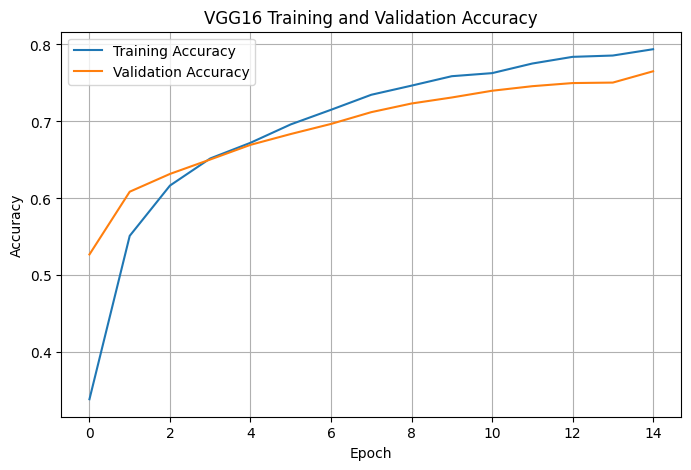

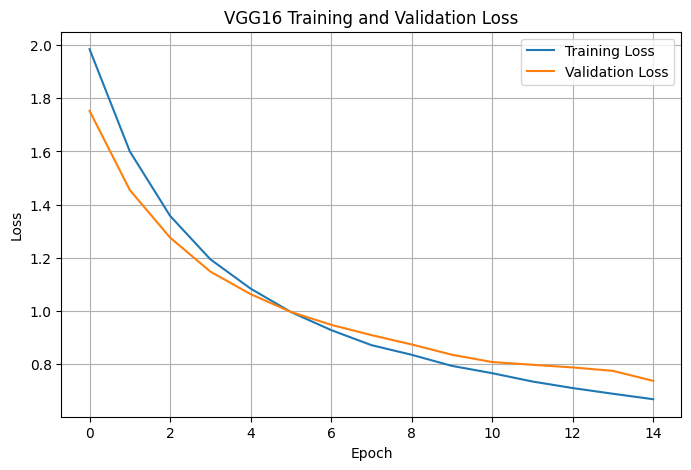

In [ ]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
loss, accuracy = model.evaluate(validation_dataset)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

101/101 ━━━━━━━━━━━━━━━━━━━━ 14s 137ms/step - accuracy: 0.7651 - loss: 0.7363
Validation Loss: 0.7363415956497192
Validation Accuracy: 0.765146791934967


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Predictions generated successfully.")

Predictions generated successfully.


In [ ]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.82      0.81      0.81       421
                        Tomato_Early_blight       0.70      0.28      0.40       185
                         Tomato_Late_blight       0.89      0.69      0.78       370
                           Tomato_Leaf_Mold       0.84      0.54      0.66       191
                  Tomato_Septoria_leaf_spot       0.72      0.74      0.73       372
Tomato_Spider_mites_Two_spotted_spider_mite       0.61      0.89      0.72       322
                        Tomato__Target_Spot       0.51      0.71      0.60       287
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.97      0.87      0.92       672
                Tomato__Tomato_mosaic_virus       0.88      0.66      0.76        68
                             Tomato_healthy       0.76      0.96      0.85       314

                                   accuracy                    

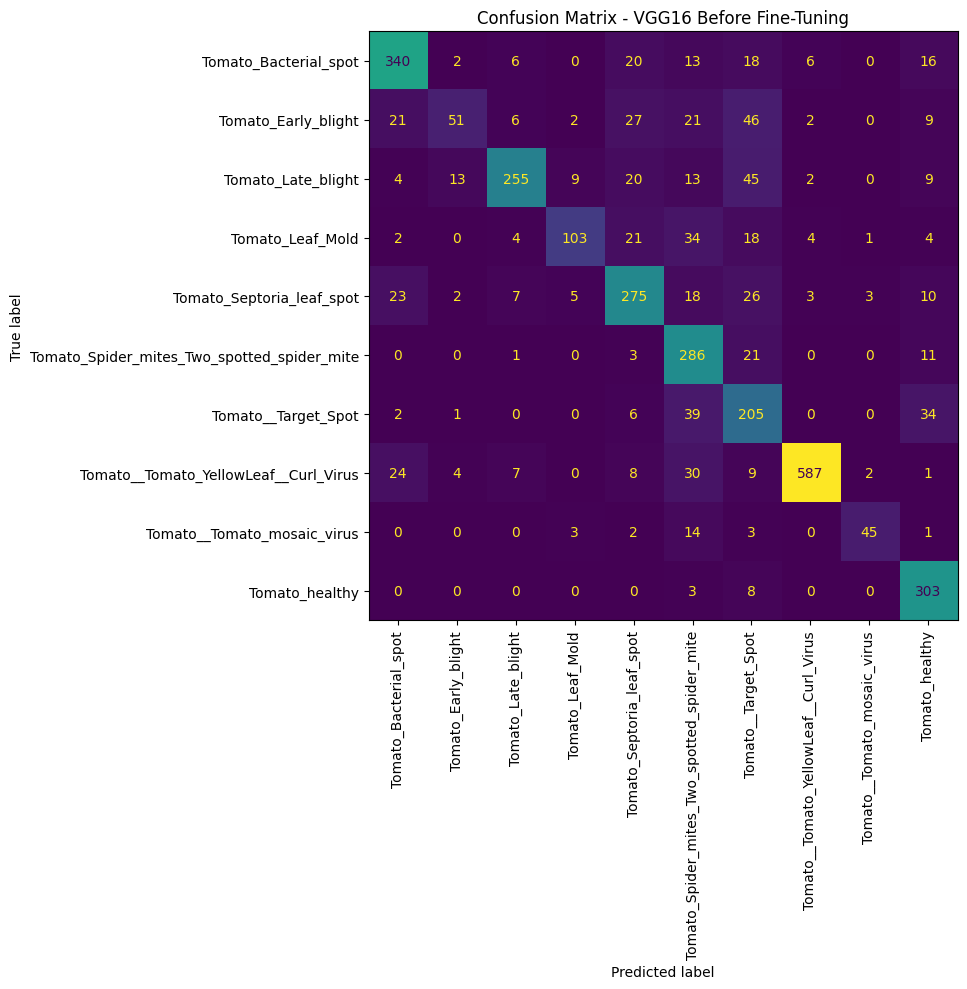

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format='d',
    colorbar=False
)

plt.title('Confusion Matrix - VGG16 Before Fine-Tuning')
plt.tight_layout()
plt.show()

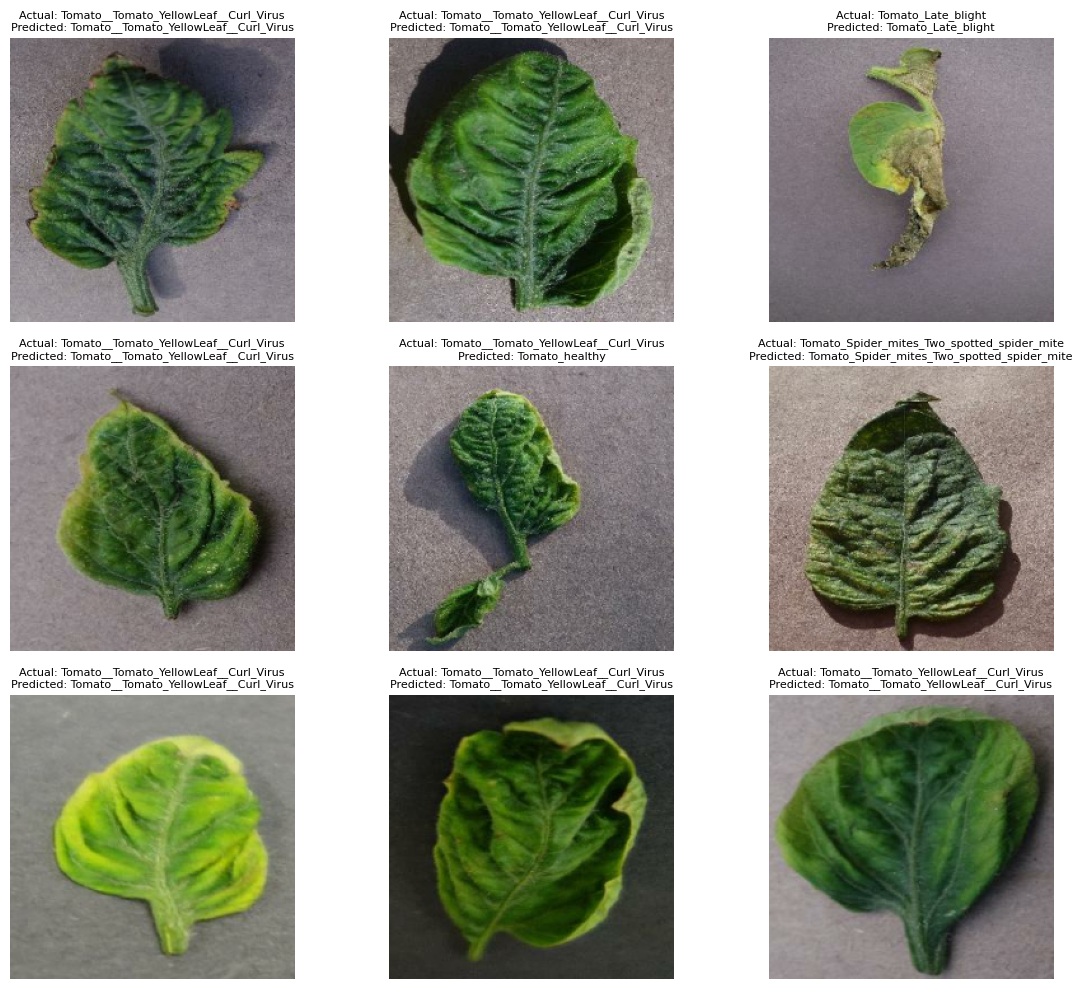

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12, 10))

for images, labels in validation_dataset.take(1):
    predictions = model.predict(images, verbose=0)

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())

        predicted_class = class_names[np.argmax(predictions[i])]
        actual_class = class_names[labels[i].numpy()]

        plt.title(
            f"Actual: {actual_class}\nPredicted: {predicted_class}",
            fontsize=8
        )

        plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Freeze all VGG16 layers first
base_model.trainable = False

# Unfreeze only the last 4 layers
for layer in base_model.layers[-4:]:
    layer.trainable = True

print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers:
block5_conv1
block5_conv2
block5_conv3
block5_pool


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled for fine-tuning.")

Model recompiled for fine-tuning.


In [ ]:
fine_tune_history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=[checkpoint]
)

Epoch 1/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step - accuracy: 0.8133 - loss: 0.5618
Epoch 1: val_accuracy improved from 0.76515 to 0.83510, saving model to /content/best_vgg16_model.keras

Epoch 1: finished saving model to /content/best_vgg16_model.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 87s 207ms/step - accuracy: 0.8374 - loss: 0.4943 - val_accuracy: 0.8351 - val_loss: 0.5120
Epoch 2/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.8816 - loss: 0.3549
Epoch 2: val_accuracy improved from 0.83510 to 0.87976, saving model to /content/best_vgg16_model.keras

Epoch 2: finished saving model to /content/best_vgg16_model.keras
401/401 ━━━━━━━━━━━━━━━━━━━━ 82s 205ms/step - accuracy: 0.8891 - loss: 0.3382 - val_accuracy: 0.8798 - val_loss: 0.3593
Epoch 3/10
401/401 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.9042 - loss: 0.2740
Epoch 3: val_accuracy did not improve from 0.87976
401/401 ━━━━━━━━━━━━━━━━━━━━ 81s 203ms/step - accuracy: 0.9130 - loss: 0.2580 - val_accuracy: 0.8654 - 

In [ ]:
fine_tune_loss, fine_tune_accuracy = model.evaluate(validation_dataset)

print("Before Fine-Tuning Accuracy: 76.51%")
print("After Fine-Tuning Accuracy:", round(fine_tune_accuracy * 100, 2), "%")
print("Fine-Tuning Loss:", round(fine_tune_loss, 4))

101/101 ━━━━━━━━━━━━━━━━━━━━ 14s 139ms/step - accuracy: 0.9163 - loss: 0.2362
Before Fine-Tuning Accuracy: 76.51%
After Fine-Tuning Accuracy: 91.63 %
Fine-Tuning Loss: 0.2362


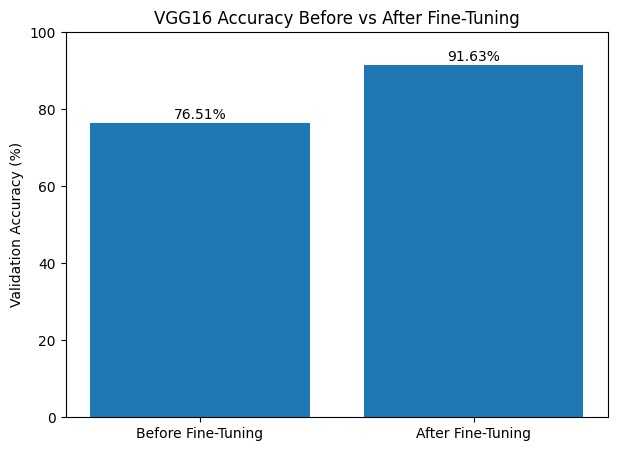

In [ ]:
import matplotlib.pyplot as plt

before_accuracy = 76.51
after_accuracy = fine_tune_accuracy * 100

plt.figure(figsize=(7, 5))

values = [before_accuracy, after_accuracy]

plt.bar(
    ['Before Fine-Tuning', 'After Fine-Tuning'],
    values
)

plt.ylabel('Validation Accuracy (%)')
plt.title('VGG16 Accuracy Before vs After Fine-Tuning')
plt.ylim(0, 100)

for i, value in enumerate(values):
    plt.text(i, value + 1, f'{value:.2f}%', ha='center')

plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

y_true_ft = []
y_pred_ft = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)

    y_true_ft.extend(labels.numpy())
    y_pred_ft.extend(np.argmax(predictions, axis=1))

y_true_ft = np.array(y_true_ft)
y_pred_ft = np.array(y_pred_ft)

print(classification_report(
    y_true_ft,
    y_pred_ft,
    target_names=class_names
))

                                             precision    recall  f1-score   support

                      Tomato_Bacterial_spot       0.94      0.96      0.95       421
                        Tomato_Early_blight       0.91      0.73      0.81       185
                         Tomato_Late_blight       0.96      0.92      0.94       370
                           Tomato_Leaf_Mold       0.99      0.58      0.73       191
                  Tomato_Septoria_leaf_spot       0.88      0.96      0.92       372
Tomato_Spider_mites_Two_spotted_spider_mite       0.88      0.91      0.89       322
                        Tomato__Target_Spot       0.73      0.96      0.83       287
      Tomato__Tomato_YellowLeaf__Curl_Virus       0.99      0.97      0.98       672
                Tomato__Tomato_mosaic_virus       0.97      0.87      0.91        68
                             Tomato_healthy       0.95      1.00      0.98       314

                                   accuracy                    

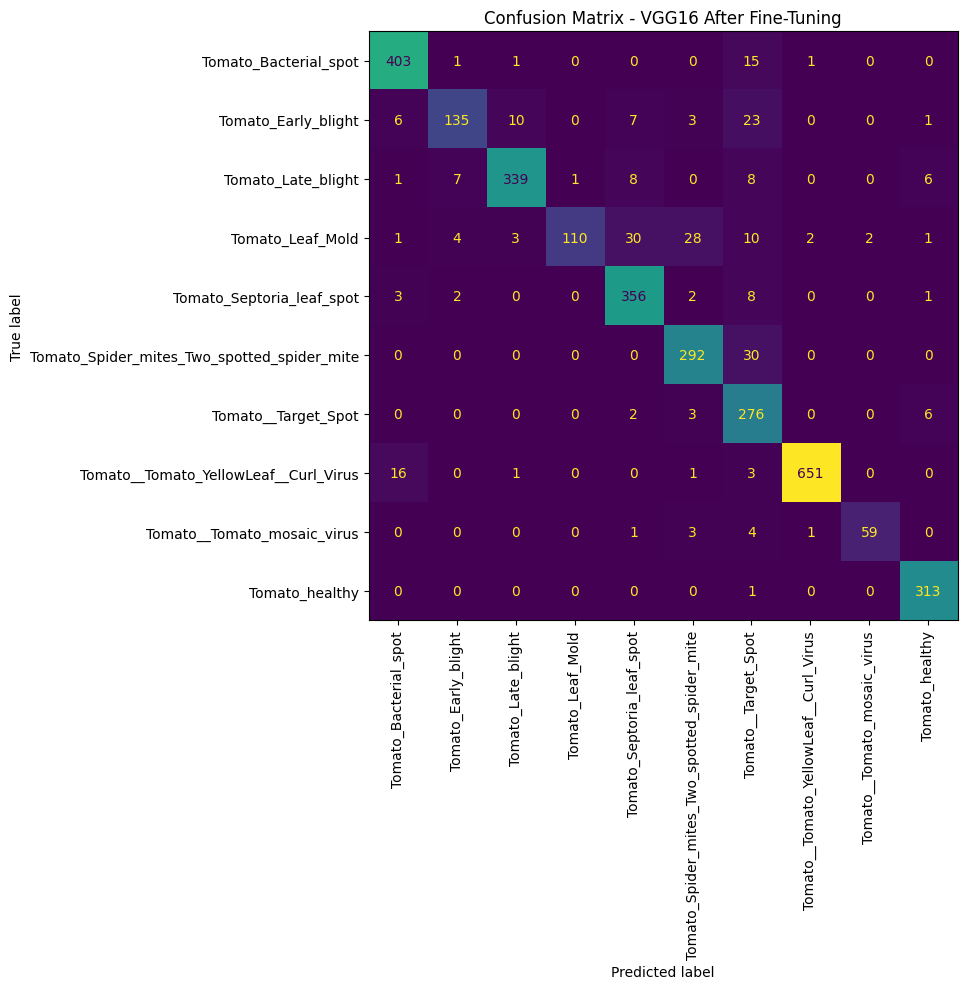

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_ft = confusion_matrix(y_true_ft, y_pred_ft)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_ft,
    display_labels=class_names
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format='d',
    colorbar=False
)

plt.title('Confusion Matrix - VGG16 After Fine-Tuning')
plt.tight_layout()
plt.show()